# Principal Component Analysis (PCA) for Multiclass Classification on MNIST Dataset

##Goal:
Implement dimensionality reduction using PCA followed by Nearest Neighbor classification on the MNIST dataset. This combines unsupervised feature extraction with a simple classifier in the reduced subspace.



In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

##LOAD Data
###Dataset: MNIST (70,000 images, 784 features)
###Train-Test Split: 80-20% (random_state=42)


In [2]:
# Load MNIST
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(float)
y = mnist.target.astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Loading MNIST...
Train: 56000 | Test: 14000


##Compute PCA
###PCA: Custom implementation using eigen-decomposition of covariance matrix


In [3]:
# ====================== PCA Function ======================
def compute_pca(X, k=50):
    mu = np.mean(X, axis=0)
    X_centered = X - mu

    # Covariance
    C = np.cov(X_centered.T)

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    # Sort by eigenvalues descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    V = eigenvectors[:, :k]   # Top k eigenvectors
    return V, mu, eigenvalues[:k]

##PCA Classification
- Reduced Dimension: M = 50 principal components
- Classifier: 1-Nearest Neighbor (1-NN) in the PCA subspace
- Distance Metric: Euclidean distance

In [4]:
# ====================== Main PCA Classification ======================
M = 50   # Number of principal components

print(f"Computing PCA with M = {M}...")
V, mu, _ = compute_pca(X_train, k=M)

# Project training data
X_train_centered = X_train - mu
phi_train = X_train_centered @ V


Computing PCA with M = 50...


In [6]:
# Project test data
X_test_centered = X_test - mu
phi_test = X_test_centered @ V

print("Classifying using Nearest Neighbour in PCA space...")

# Nearest Neighbour Classification
y_pred = np.zeros(len(y_test), dtype=int)

for i in range(len(y_test)):
    dist = np.sum((phi_train - phi_test[i])**2, axis=1)
    nn_idx = np.argmin(dist)
    y_pred[i] = y_train[nn_idx]

Classifying using Nearest Neighbour in PCA space...


##Results

In [7]:
# Accuracy
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nFinal Test Accuracy with M={M}: {acc:.2f}%")


Final Test Accuracy with M=50: 97.51%


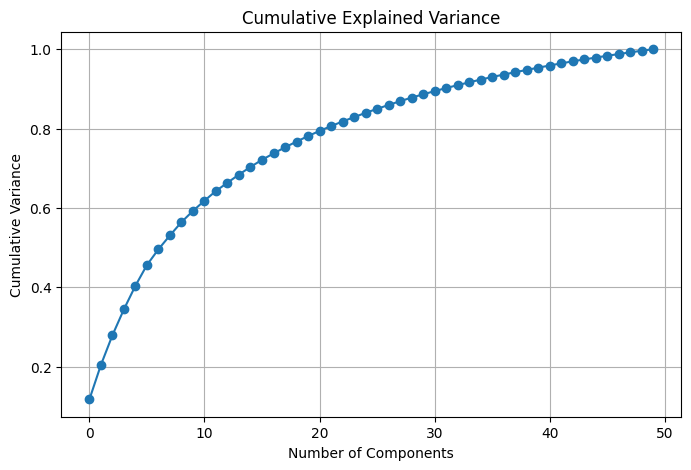

In [8]:
# Optional: Plot explained variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(_)/np.sum(_), 'o-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.grid(True)
plt.show()

##Results

- Test Accuracy: 97.51% (with M=50), Training Samples: ~56,000, Test Samples: ~14,000
- Using only 50 dimensions (instead of original 784), we retain sufficient information to achieve good classification performance with 1-NN.
- The significant reduction in dimensionality leads to faster computation during nearest neighbor search.
- Some confusion is expected between visually similar digits (e.g., 4↔9, 3↔5, 7↔9).
- The cumulative explained variance plot shows that the top 50 principal components capture a substantial portion of the data’s variability, justifying the choice of M=50

##Key Learnings

- PCA is an effective preprocessing step that removes redundancy and noise while preserving important structure.
- Working in a lower-dimensional space makes distance-based methods like Nearest Neighbor much more efficient.
- Linear dimensionality reduction + simple classifier can serve as a strong baseline before moving to more complex models (e.g., CNNs).

###Limitations

- Nearest Neighbor classifier has slow inference time (O(N) per test sample).
- PCA is a linear method and may not capture highly non-linear variations in handwriting.
- No hyperparameter tuning was performed (e.g., different values of M or k-NN).